In [9]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

### Comparing Steering Method and Datasets

### Stereotyping in NYT Book Opinions

### Biased Coin Flip Experiments

### NYT Book Opinion Disagreement

In [ ]:
import json
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

In [ ]:
repub_df_1 = pd.read_csv('/Users/nicolemeister/Desktop/STANFORD/distributions/results/human_annotations/NYTimes Data Collection - Republican_May 27, 2024_15.36.csv')
repub_df_1 = repub_df_1.drop(index=[0, 1])

dem_df_1 = pd.read_csv('/Users/nicolemeister/Desktop/STANFORD/distributions/results/human_annotations/NYTimes Data Collection - Democrat_May 27, 2024_15.58.csv')
dem_df_1 = dem_df_1.drop(index=[0, 1])

repub_df_2 = pd.read_csv('/Users/nicolemeister/Desktop/STANFORD/distributions/results/human_annotations/NYTimes Data Collection - Republican - V2_May 27, 2024_22.33.csv')
repub_df_2 = repub_df_2.drop(index=[0, 1])

dem_df_2 = pd.read_csv('/Users/nicolemeister/Desktop/STANFORD/distributions/results/human_annotations/NYTimes Data Collection - Democrat - V2_May 27, 2024_22.33.csv')
dem_df_2 = dem_df_2.drop(index=[0, 1])

In [ ]:
dem_df = pd.concat([dem_df_1, dem_df_2], ignore_index=True, sort=False)
repub_df = pd.concat([repub_df_1, repub_df_2], ignore_index=True, sort=False)

In [ ]:
combined_df = pd.concat([dem_df, repub_df],  ignore_index=True, sort=False)
col_to_keep = ['QDem_Gend', 'QDem_Race', 'Q_DemRepub', 'QDem_Income', 'Q84', 'QDem_Age'] # demographics
combined_df = combined_df[col_to_keep]
combined_df.to_csv('/Users/nicolemeister/Desktop/STANFORD/distributions/results/human_annotations/nytimes_annotator_demographics.csv')

In [ ]:
data = pd.read_csv('/Users/nicolemeister/Desktop/STANFORD/distributions/results/human_annotations/NYTIMES_BOOK_DATASET.csv')

In [ ]:
qualtricsID_to_title, title_to_qualtricsID = {}, {}
col_to_keep = ['Q84', 'QDem_Age', 'QDem_Gend', 'QDem_Race', 'Q_DemRepub', 'QDem_Income'] # demographics
booktitles = np.array(data['Title and Author'])
genres = np.array(data['Genre'])
summaries = np.array(data['Summary'])
for i, qualtricsID in enumerate([1] + list(np.arange(307, 333))+ list(np.arange(334, 385))+ list(np.arange(386, 408)) + [100] + list(np.arange(408,542))):
  col_to_keep.append(str(qualtricsID)+'_Q138')
  if str(qualtricsID)+'_Q138' not in repub_df.columns: print(str(qualtricsID)+'_Q138')
  qualtricsID_to_title[qualtricsID] = booktitles[i]
  title_to_qualtricsID[booktitles[i]] = qualtricsID

In [ ]:
repub_df = repub_df[col_to_keep]
dem_df = dem_df[col_to_keep]

dem_df['QDem_Age'] = dem_df['QDem_Age'].astype(int)
repub_df['QDem_Age'] = repub_df['QDem_Age'].astype(int)

In [ ]:
# male female
male_df = pd.concat([repub_df[repub_df['QDem_Gend']=='Male'], dem_df[dem_df['QDem_Gend']=='Male']], ignore_index=True, sort=False)
female_df = pd.concat([repub_df[repub_df['QDem_Gend']=='Female'], dem_df[dem_df['QDem_Gend']=='Female']], ignore_index=True, sort=False)

repub_df = repub_df[repub_df['Q_DemRepub']=='Republican']
dem_df = dem_df[dem_df['Q_DemRepub']=='Democrat']



In [ ]:
len(male_df), len(female_df), len(repub_df), len(dem_df) 

(131, 206, 165, 172)

In [ ]:
dem_values, repub_values, male_values, female_values = [], [], [], []
dem_data, repub_data, male_data, female_data = [], [], [], []
dem_id_data, repub_id_data, male_id_data, female_id_data = [], [], [], []
for i, qualtricsID in enumerate([1] + list(np.arange(307, 333))+ list(np.arange(334, 385))+ list(np.arange(386, 408)) + [100] + list(np.arange(408,542))):
    # print(str(qualtricsID)+'_Q138')
    non_nan_values = np.array(dem_df[str(qualtricsID)+'_Q138'].dropna())
    non_nan_prolific_ids = dem_df['Q84'][~pd.isna(dem_df[str(qualtricsID)+'_Q138'])]
    dem_data.append(non_nan_values)
    dem_id_data.append(dict(zip(non_nan_prolific_ids, non_nan_values)))
    dem_values.append(len(non_nan_values))

    non_nan_values = np.array(repub_df[str(qualtricsID)+'_Q138'].dropna())
    non_nan_prolific_ids = repub_df['Q84'][~pd.isna(repub_df[str(qualtricsID)+'_Q138'])]
    repub_data.append(non_nan_values)
    repub_id_data.append(dict(zip(non_nan_prolific_ids, non_nan_values)))
    repub_values.append(len(non_nan_values))

    non_nan_values = np.array(male_df[str(qualtricsID)+'_Q138'].dropna())
    non_nan_prolific_ids = male_df['Q84'][~pd.isna(male_df[str(qualtricsID)+'_Q138'])]
    male_id_data.append(dict(zip(non_nan_prolific_ids, non_nan_values)))
    male_data.append(non_nan_values)
    male_values.append(len(non_nan_values))

    non_nan_values = np.array(female_df[str(qualtricsID)+'_Q138'].dropna())
    non_nan_prolific_ids = female_df['Q84'][~pd.isna(female_df[str(qualtricsID)+'_Q138'])]
    female_id_data.append(dict(zip(non_nan_prolific_ids, non_nan_values)))
    female_data.append(non_nan_values)
    female_values.append(len(non_nan_values))

dem_data = np.array(dem_data, dtype=object)
repub_data = np.array(repub_data, dtype=object)

male_data = np.array(male_data, dtype=object)
female_data = np.array(female_data, dtype=object)

In [ ]:
# convert all the labels to numbers
labels_to_num = {'1: Very unlikely':1 , '2: Somewhat unlikely':2, '3: Somewhat likely':3, '4: Very likely': 4}
def get_nums(x):
    return labels_to_num[x]

vectorized_function = np.vectorize(get_nums)

# Apply the vectorized function to the array
dem_data_nums = []
for i in range(len(dem_data)):
    dem_data_nums.append(vectorized_function(dem_data[i]))

repub_data_nums = []
for i in range(len(repub_data)):
    repub_data_nums.append(vectorized_function(repub_data[i]))

male_data_nums = []
for i in range(len(male_data)):
    male_data_nums.append(vectorized_function(male_data[i]))

female_data_nums = []
for i in range(len(female_data)):
    female_data_nums.append(vectorized_function(female_data[i]))

In [ ]:
num_to_label = {1: '1: Very unlikely', 2: '2: Somewhat unlikely', 3: '3: Somewhat likely', 4: '4: Very likely'}


count = 0 
all = []
proportions_data_annotator_id = defaultdict(dict)
for i, book_title in enumerate(booktitles): 
    book_title=str(book_title)
    proportions_data_annotator_id[book_title]['MC_options']=list(['1: Very unlikely', '2: Somewhat unlikely', '3: Somewhat likely', '4: Very likely'])
    proportions_data_annotator_id[book_title]['genre']= genres[i]
    proportions_data_annotator_id[book_title]['summary']= summaries[i]
    
    proportions_data_annotator_id[book_title]['Democrat'] = dem_id_data[i]
    proportions_data_annotator_id[book_title]['Republican'] = repub_id_data[i]
    proportions_data_annotator_id[book_title]['Male'] = male_id_data[i]
    proportions_data_annotator_id[book_title]['Female'] = female_id_data[i]

    all.append(len(dem_id_data[i].keys()))
    all.append(len(repub_id_data[i].keys()))
    all.append(len(male_id_data[i].keys()))
    all.append(len(female_id_data[i].keys()))
    count += len(dem_id_data[i].keys())+len(repub_id_data[i].keys())+len(male_id_data[i].keys())+len(female_id_data[i].keys())

print(count)

17570


In [ ]:

def count_keys(keys, lst):
    # Initialize a dictionary with all keys set to 0
    key_counts = {key: 0 for key in keys}
    
    # Count occurrences of each key in the list
    for item in lst:
        if item in key_counts:
            key_counts[item] += 1
    
    return key_counts

mc_options = [1, 2, 3, 4]

def get_label_to_counts(my_list):
    print(my_list)
    label_to_count = count_keys(mc_options, my_list)
    print(label_to_count)
    # labels, counts = np.unique(my_list, return_counts=True)
    # label_to_count = dict(zip(labels,counts))
    converted_data = {num_to_label[k]: int(v) for k, v in label_to_count.items()}
    return converted_data


proportions_data = defaultdict(dict)
for i, book_title in enumerate(booktitles): 
    book_title=str(book_title)
    proportions_data[book_title]['MC_options']=list(['1: Very unlikely', '2: Somewhat unlikely', '3: Somewhat likely', '4: Very likely'])
    proportions_data[book_title]['genre']= genres[i]
    proportions_data[book_title]['summary']= summaries[i]
    
    proportions_data[book_title]['Democrat'] = get_label_to_counts(dem_data_nums[i])
    proportions_data[book_title]['Republican'] = get_label_to_counts(repub_data_nums[i])
    proportions_data[book_title]['Male'] = get_label_to_counts(male_data_nums[i])
    proportions_data[book_title]['Female'] = get_label_to_counts(female_data_nums[i])


[1 2 1 4 3 1 3 2 1 1 2 1 1 2 2 2 1 1 3 4]
{1: 9, 2: 6, 3: 3, 4: 2}
[1 4 1 2 2 3 2 3 3 1 3 1 1 2 1 1 2 4 3]
{1: 7, 2: 5, 3: 5, 4: 2}
[4 3 2 2 3 1 1 1 2 1 2 3 1 1 1 2 3]
{1: 7, 2: 5, 3: 4, 4: 1}
[1 1 2 3 3 3 1 4 2 1 4 3 3 2 1 1 2 1 2 1 1 4]
{1: 9, 2: 5, 3: 5, 4: 3}
[4 3 3 3 4 3 3 4 4 1 3 4 1 1 4 4 1 1 1 4]
{1: 6, 2: 0, 3: 6, 4: 8}
[4 1 4 2 3 4 1 1 1 3 1 2 3 3 2 3 2]
{1: 5, 2: 4, 3: 5, 4: 3}
[4 2 4 3 4 1 1 3 3 2 2 4 3 1 4 1]
{1: 4, 2: 3, 3: 4, 4: 5}
[1 2 1 1 3 2 3 4 3 3 3 3 4 4 3 4 1 1 4 1 1 4]
{1: 7, 2: 2, 3: 7, 4: 6}
[2 1 2 2 1 3 1 1 1 3 2 1 1 2 3 1 1 2 2]
{1: 9, 2: 7, 3: 3, 4: 0}
[3 2 2 1 4 3 2 3 2 2 2 3 3 4 3 3 4 4]
{1: 1, 2: 6, 3: 7, 4: 4}
[3 3 2 2 2 3 4 3 3 4 2 3 1 1 2]
{1: 2, 2: 5, 3: 6, 4: 2}
[2 2 1 4 3 2 3 4 1 2 2 1 3 1 1 1 2 1 2 3 1 2]
{1: 8, 2: 8, 3: 4, 4: 2}
[4 2 3 4 3 2 1 3 1 1 2 1 1 1 1 1 1 2 1 1 1]
{1: 12, 2: 4, 3: 3, 4: 2}
[3 3 1 2 4 1 2 3 4 3 2 4 3 2 3 3 3 4]
{1: 2, 2: 4, 3: 8, 4: 4}
[3 1 4 2 3 2 4 2 3 3 4 2 3 2 1]
{1: 2, 2: 5, 3: 5, 4: 3}
[3 2 4 1 2 3 4 3 3 4 4 2 3 4 3 1

In [ ]:
# Specify the filename
filename = '/Users/nicolemeister/Desktop/STANFORD/distributions/NYTIMES/NYTIMES_proportions.json'

# Open the file in write mode and use json.dump to write the dictionary to the file
with open(filename, 'w') as file:
    json.dump(proportions_data, file, indent=4)

#### Finding top 10 similar books 

In [ ]:
from fuzzywuzzy import fuzz
from simcse import SimCSE
from sklearn.metrics.pairwise import cosine_similarity

model = SimCSE("princeton-nlp/sup-simcse-bert-base-uncased")

In [ ]:
#### TOP 10 similar questions
import json
data_filename = '/Users/nicolemeister/Desktop/STANFORD/distributions/NYTIMES/NYTIMES_proportions.json'

with open(data_filename, 'r') as json_file:
    data = json.load(json_file)

question_similarity = {}
# map question IDs to embeddings 
question_ID_to_embedding = {}

# go through all the questions in all the waves and calc text embeddings


for q_ID in list(data.keys()):
    prompt=''
    prompt+= "\nBook Title: " + q_ID 
    prompt+= "\nBook Genre: " + data[q_ID]['genre'] 
    prompt+= "\nBook Summary: " + data[q_ID]['summary'] 
    embeddings = np.array(model.encode(prompt).tolist()).reshape(-1, 1)
    question_ID_to_embedding[q_ID] = embeddings


100%|██████████| 1/1 [00:00<00:00,  1.70it/s]


In [ ]:
for question_ID in data.keys():
    question_IDs, question_IDs_similarity = [], []
    
    for question_ID_other in data.keys():
        if question_ID_other!=question_ID: 
            question_IDs.append(question_ID_other)

            # find similar keys by comparing question ID
            a, b = question_ID_to_embedding[question_ID], question_ID_to_embedding[question_ID_other] 
            norm = np.linalg.norm(a - b) # smaller is more similar 
            question_IDs_similarity.append(norm)
    
    sorted_pairs = sorted(zip(question_IDs_similarity, question_IDs))
    sorted_listA = [pair[1] for pair in sorted_pairs]
    question_similarity[question_ID] = sorted_listA[:10]

In [ ]:
# save data 
with open('/Users/nicolemeister/Desktop/STANFORD/distributions/NYTIMES/question_similarity_top10.json', "w") as json_file:
    json.dump(question_similarity, json_file)

#### Data analysis

In [ ]:
repub_data_nums = np.array(repub_data_nums, dtype=object)
dem_data_nums = np.array(dem_data_nums, dtype=object)
male_data_nums = np.array(male_data_nums, dtype=object)
female_data_nums = np.array(female_data_nums, dtype=object)

In [ ]:
def get_bootstrapping_errors(input_data):     
    data = list(input_data)

    # Number of bootstrap samples
    num_bootstraps = 1000

    # Function to compute the statistic of interest (mean, median, etc.)
    def compute_statistic(sample):
        return np.mean(sample)  # Example: computing the mean

    # Bootstrapping process
    bootstrap_statistics = []
    for _ in range(num_bootstraps):
        bootstrap_sample = np.random.choice(data, size=len(data), replace=True)
        statistic = compute_statistic(bootstrap_sample)
        bootstrap_statistics.append(statistic)

    # Compute confidence interval (e.g., 95% confidence interval)
    confidence_level = 0.95
    alpha = (1 - confidence_level) / 2
    lower_percentile = alpha * 100
    upper_percentile = (1 - alpha) * 100
    lower_bound = np.percentile(bootstrap_statistics, lower_percentile)
    upper_bound = np.percentile(bootstrap_statistics, upper_percentile)

    bs_error = (upper_bound-lower_bound)/2

    return bs_error


In [ ]:
repub_means, repub_errors, dem_means, dem_errors = [], [], [], []
male_means, male_errors, female_means, female_errors = [], [], [], []

for repub_value in repub_data_nums: 
    repub_means.append(np.mean(repub_value))
    repub_errors.append(get_bootstrapping_errors(repub_value))

for dem_value in dem_data_nums: 
    dem_means.append(np.mean(dem_value))
    dem_errors.append(get_bootstrapping_errors(dem_value))

for male_value in male_data_nums: 
    male_means.append(np.mean(male_value))
    male_errors.append(get_bootstrapping_errors(male_value))

for female_value in female_data_nums: 
    female_means.append(np.mean(female_value))
    female_errors.append(get_bootstrapping_errors(female_value))

repub_means=np.array(repub_means)
repub_errors=np.array(repub_errors)
dem_means=np.array(dem_means)
dem_errors = np.array(dem_errors)

male_means=np.array(male_means)
male_errors = np.array(male_errors)

female_means=np.array(female_means)
female_errors = np.array(female_errors)

# repub_means = repub_data_nums.mean(axis=1)
# repub_errors = repub_data_nums.std(axis=1)  
# dem_means = dem_data_nums.mean(axis=1)
# dem_errors = dem_data_nums.std(axis=1)  

In [ ]:
max_ind, min_ind = np.argmax(repub_means - dem_means), np.argmin(repub_means - dem_means)
max_ind, min_ind = np.argsort(repub_means - dem_means)[-5:][::-1], np.argsort(repub_means - dem_means)[:5][::-1]

print("MAX REPUB-DEM")
for i in max_ind:
    print('Max(Repub-Dem): {}\nBook Title: {}\n Book Summary: {}'.format((repub_means - dem_means)[i], booktitles[i], summaries[i]))
print("MIN REPUB-DEM")
for i in min_ind:
    print('Min(Repub-Dem): {}\nBook Title: {}\n Book Summary: {}'.format((repub_means - dem_means)[i], booktitles[i], summaries[i]))

max_ind, min_ind = np.argmax(male_means - female_means), np.argmin(male_means - female_means)
max_ind, min_ind = np.argsort(male_means - female_means)[-5:][::-1], np.argsort(male_means - female_means)[:5][::-1]

print("MAX MALE-FEMALE")
for i in max_ind:
    print('Max(Male-Female): {}\nBook Title: {}\n Book Summary: {}'.format((male_means - female_means)[i], booktitles[i], summaries[i]))
print("MIN MALE-FEMALE")
for i in min_ind:
    print('Min(Male-Female): {}\nBook Title: {}\n Book Summary: {}'.format((male_means - female_means)[i], booktitles[i], summaries[i]))

MAX REPUB-DEM
Max(Repub-Dem): 1.263157894736842
Book Title: Redeployment By Phil Klay
 Book Summary: Twelve stories by a former Marine who served in Iraq capture on an intimate scale the ways in which the war there evoked a unique array of emotion, predicament and heartbreak.
Max(Repub-Dem): 1.1549707602339183
Book Title: Washington'S Crossing By David Hackett Fischer
 Book Summary: how a daring venture across the Delaware on Christmas night 1776 defeated the British at Trenton and changed the dynamic of the Revolutionary War.
Max(Repub-Dem): 1.0935672514619883
Book Title: Eastbound By Maylis De Kerangal
 Book Summary: In de Kerangal’s brief, lyrical novel, translated by Jessica Moore, a young Russian soldier on a trans-Siberian train decides to desert and turns to a civilian passenger, a Frenchwoman, for help.
Max(Repub-Dem): 1.05
Book Title: The Story Of The Lost Child By Elena Ferrante
 Book Summary: Friends confront age and the questions of life’s meaning in the stunning final book

In [ ]:
max_ind, min_ind = np.argmax(repub_means - dem_means), np.argmin(repub_means - dem_means)

max_ind, min_ind = np.argsort(repub_means - dem_means)[-4:][::-1], np.argsort(repub_means - dem_means)[:4][::-1]

dem_plot_means, repub_plot_means, dem_plot_std, repub_plot_std, booktitles_plot  = [], [], [], [], []
for i in max_ind:
    print('Max(Repub-Dem): {}\nBook Title: {}\n Book Summary: {}'.format((repub_means - dem_means)[i], booktitles[i], summaries[i]))
    dem_plot_means.append(dem_means[i])
    dem_plot_std.append(dem_errors[i])
    repub_plot_means.append(repub_means[i])
    repub_plot_std.append(repub_errors[i])
    booktitles_plot.append(booktitles[i])
for i in min_ind:
    print('Min(Repub-Dem): {}\nBook Title: {}\n Book Summary: {}'.format((repub_means - dem_means)[i], booktitles[i], summaries[i]))
    dem_plot_means.append(dem_means[i])
    dem_plot_std.append(dem_errors[i])
    repub_plot_means.append(repub_means[i])
    repub_plot_std.append(repub_errors[i])
    booktitles_plot.append(booktitles[i])

Max(Repub-Dem): 1.263157894736842
Book Title: Redeployment By Phil Klay
 Book Summary: Twelve stories by a former Marine who served in Iraq capture on an intimate scale the ways in which the war there evoked a unique array of emotion, predicament and heartbreak.
Max(Repub-Dem): 1.1549707602339183
Book Title: Washington'S Crossing By David Hackett Fischer
 Book Summary: how a daring venture across the Delaware on Christmas night 1776 defeated the British at Trenton and changed the dynamic of the Revolutionary War.
Max(Repub-Dem): 1.0935672514619883
Book Title: Eastbound By Maylis De Kerangal
 Book Summary: In de Kerangal’s brief, lyrical novel, translated by Jessica Moore, a young Russian soldier on a trans-Siberian train decides to desert and turns to a civilian passenger, a Frenchwoman, for help.
Max(Repub-Dem): 1.05
Book Title: The Story Of The Lost Child By Elena Ferrante
 Book Summary: Friends confront age and the questions of life’s meaning in the stunning final book of this brill

In [ ]:
labels = ['Redeployment \n by P. Klay',
 "Washington's \n Crossing \n by D.H. Fischer",
 'Eastbound \n by M. Kerangal',
 'The Story Of \nThe Lost Child \n by E. Ferrante',
#  'The Fraud \n by Zadie Smith',
#  'White Teeth \n by Zadie Smith',
 'A Promised Land \n by B. Obama',
 'A Short History\n Of Women \n by K. Walbert',
 'Ten Thousand\n Saints \n by \n E. Henderson',
 'Nw \n by Z. Smith']

In [ ]:
# Setting font sizes and scaling other parameters
scale_factor = 2
plt.rcParams.update({
    'font.size': 18 * scale_factor,          # Default text size
    'axes.titlesize': 16 * scale_factor,     # Axes title size
    'axes.labelsize': 22 * scale_factor,     # Axes label size
    'xtick.labelsize': 24 * scale_factor,    # X-tick label size
    'ytick.labelsize': 14 * scale_factor,    # Y-tick label size
    'legend.fontsize': 22 * scale_factor,    # Legend font size
    'figure.titlesize': 18 * scale_factor    # Figure title size
})


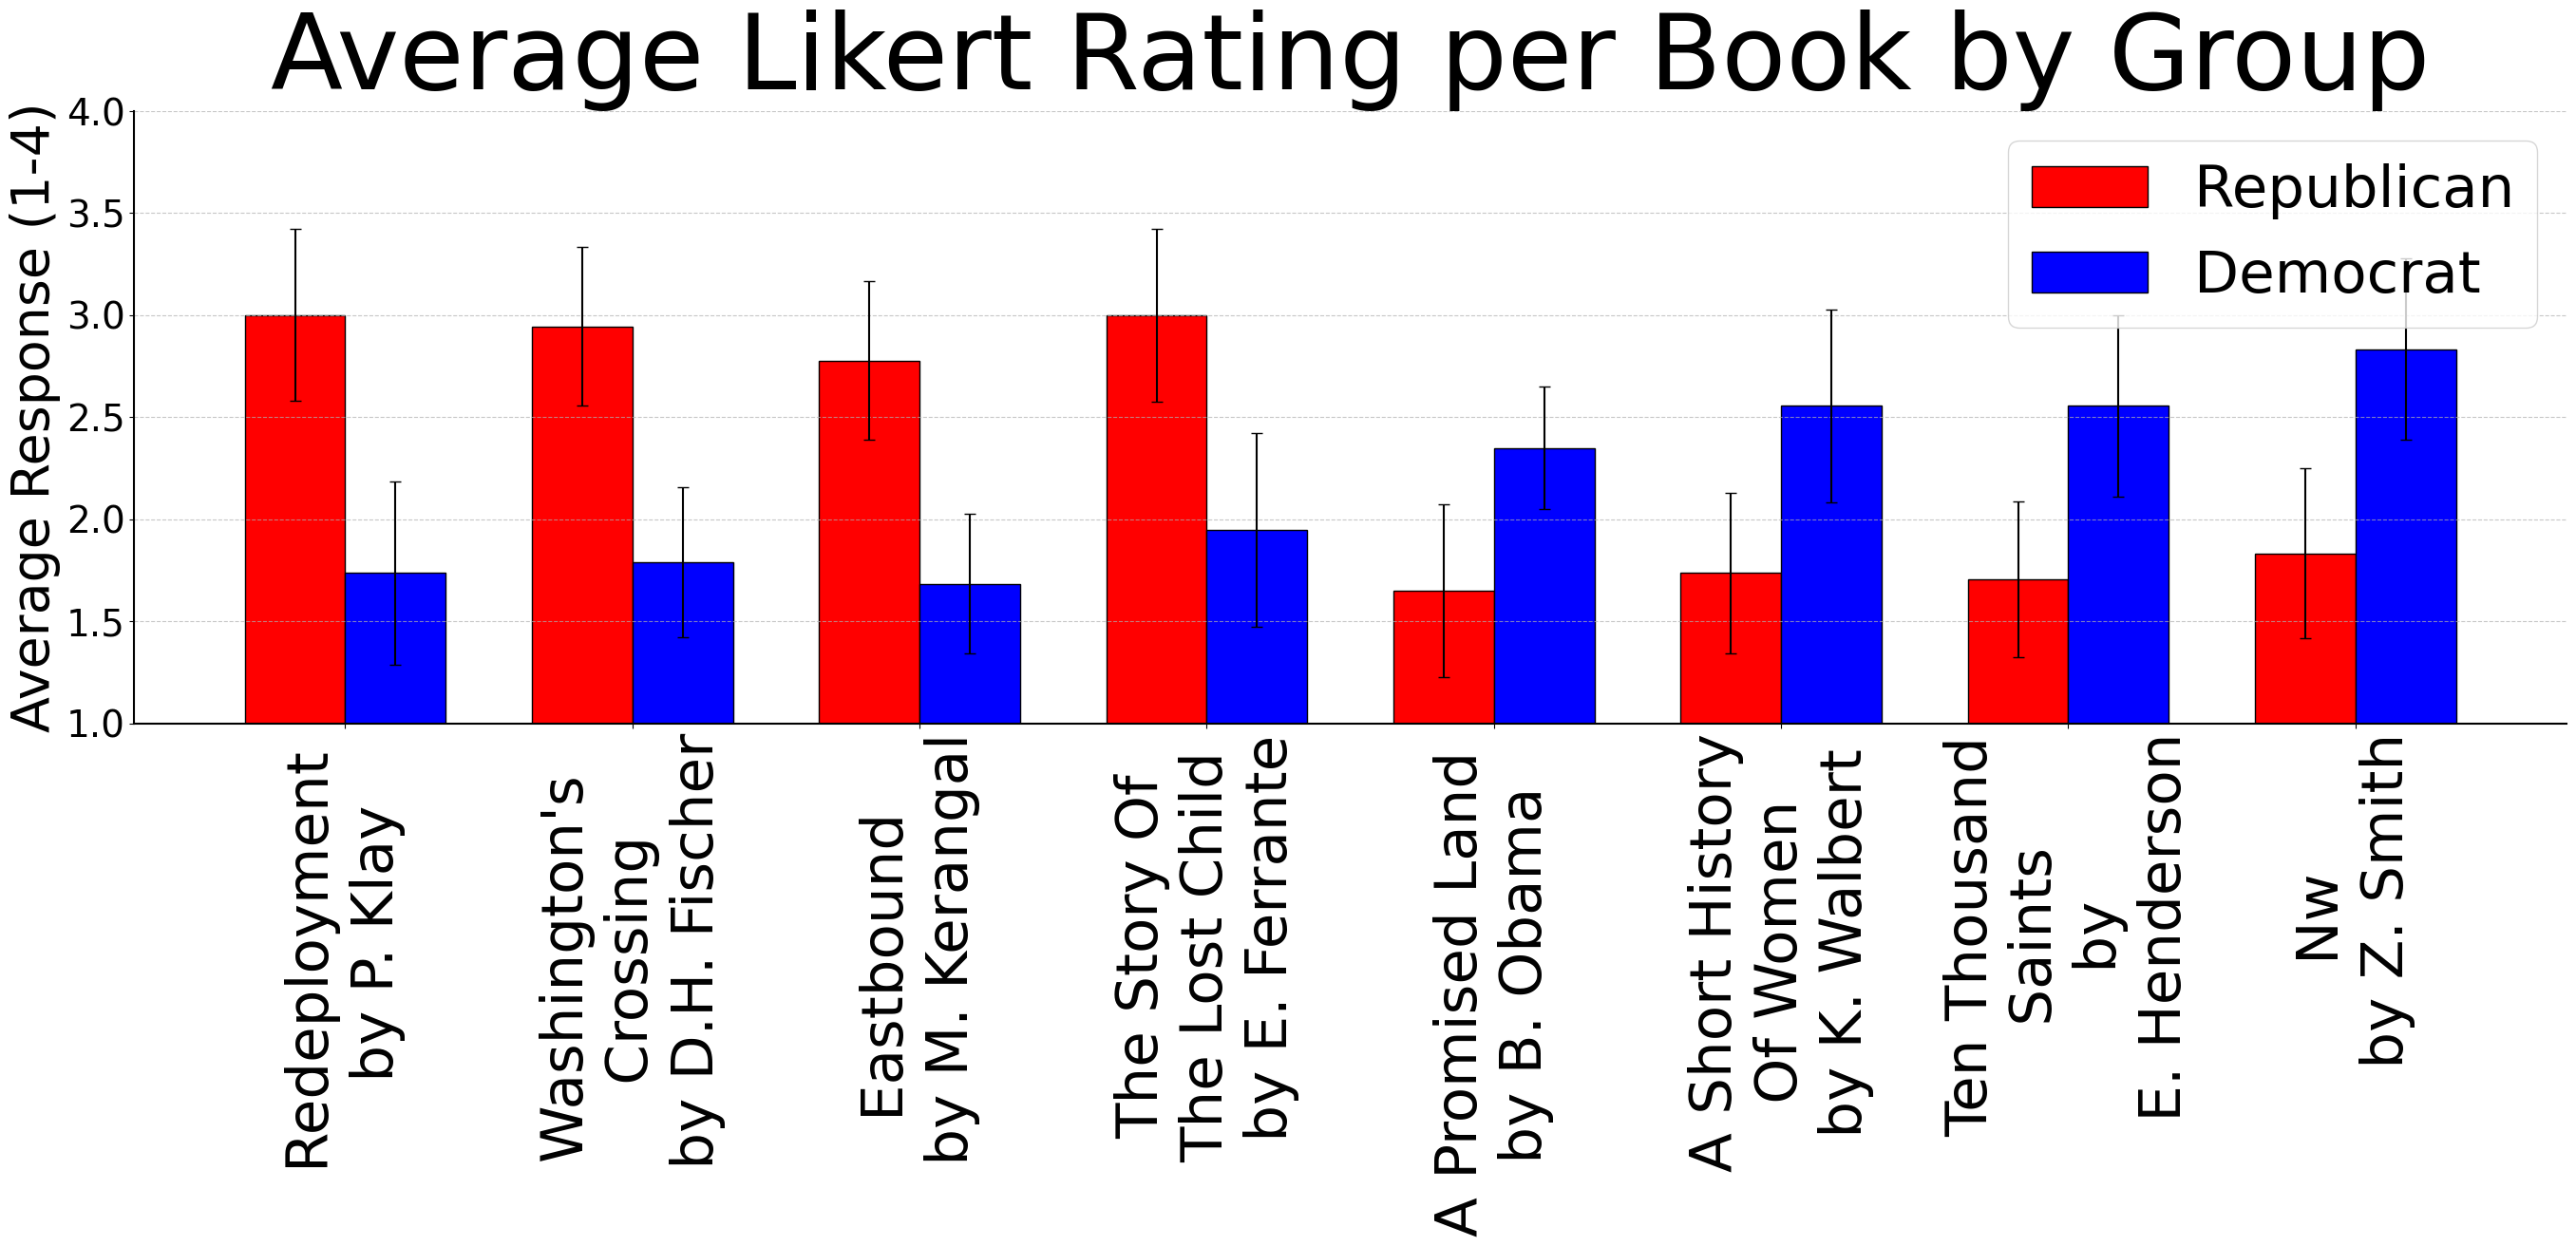

In [ ]:
# labels = booktitles_plot

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(14*scale_factor, 7*scale_factor))

# Plotting group 1 bars
bars1 = ax.bar(x - width/2, repub_plot_means, width, yerr=repub_plot_std, capsize=4, label='Republican', color='red', edgecolor='black')

# Plotting group 2 bars
bars2 = ax.bar(x + width/2, dem_plot_means, width, yerr=dem_plot_std, capsize=4, label='Democrat', color='blue', edgecolor='black')

# Adding labels, title, and custom x-axis tick labels
# ax.set_xlabel('Books', fontsize=22*scale_factor)
ax.set_ylabel('Average Response (1-4)', fontsize=20*scale_factor)
ax.set_title('Average Likert Rating per Book by Group', fontsize=40*scale_factor)
ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.tick_params(axis='x', rotation=90)

ax.set_ylim([1, 4])
ax.legend()

# Adding a grid
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Improving the layout
plt.tight_layout()
# Removing the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adjusting the bottom and left spines
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)


# Displaying the plot
plt.tight_layout()
plt.xticks()
plt.savefig('/Users/nicolemeister/Desktop/STANFORD/distributions/figures/nytimes_final.pdf')
plt.show()

#### Cohens Kappa: In group and Out Group

In [ ]:
# Goal 1: Calculate the cohens kappa between each group (in group)
# Goal 2: Calculate the cohens kappa between each group and the opposing group (out group)


# step 1: make all the democrat and republican ratings the same size 

In [ ]:
repub_data_nums[0]

array([1, 4, 1, 2, 2, 3, 2, 3, 3, 1, 3, 1, 1, 2, 1, 1, 2, 4, 3])

In [ ]:
import pandas as pd
book_ids, group, ratings = [], [], []
for book_id in range(len(repub_data_nums)):
    for i in repub_data_nums[book_id]:
        book_ids.append(book_id)
        group.append('Republican')
        ratings.append(repub_data_nums[book_id][i])

    for i in dem_data_nums[book_id]:
        book_ids.append(book_id)
        group.append('Democrat')
        ratings.append(dem_data_nums[book_id][i])

data = {
    'book_id': book_ids,   # Book IDs
    'group': group,  # Group identifiers
    'ratings': ratings   # Ratings given
}

df_both = pd.DataFrame(data)

In [ ]:
from sklearn.metrics import cohen_kappa_score
# Aggregate ratings to handle duplicates
df_agg = df_both.groupby(['book_id', 'group']).agg({'ratings': 'mean'}).reset_index()


# Pivot the DataFrame
pivot_df = df_agg.pivot(index='book_id', columns='group', values='ratings')

# Ensure both columns are present for kappa calculation
if 'Democrat' in pivot_df.columns and 'Republican' in pivot_df.columns:
    # Extract the ratings into two separate lists
    democrats_ratings = pivot_df['Democrat'].dropna().values
    republicans_ratings = pivot_df['Republican'].dropna().values

    # Define bin edges and labels
    bin_edges = np.linspace(min(democrats_ratings.min(), republicans_ratings.min()), 
                            max(democrats_ratings.max(), republicans_ratings.max()), 
                            num=4)  # Adjust num for more or fewer bins
    bin_labels = [f'Bin{i}' for i in range(len(bin_edges)-1)]

    # Bin the ratings
    democrats_binned = pd.cut(democrats_ratings, bins=bin_edges, labels=bin_labels, include_lowest=True)
    republicans_binned = pd.cut(republicans_ratings, bins=bin_edges, labels=bin_labels, include_lowest=True)
    
    # Convert to categorical codes
    democrats_codes = democrats_binned.codes
    republicans_codes = republicans_binned.codes
    
    # Calculate Cohen's Kappa
    kappa = cohen_kappa_score(democrats_codes, republicans_codes)
    print(f"Cohen's Kappa: {kappa}")
else:
    print("Error: Both Democrat and Republican ratings must be present.")

Cohen's Kappa: 0.054805035308566064


In [ ]:
import pandas as pd
book_ids, group, ratings = [], [], []
for book_id in range(len(male_data_nums)):
    for i in male_data_nums[book_id]:
        book_ids.append(book_id)
        group.append('Male')
        ratings.append(male_data_nums[book_id][i])

    for i in female_data_nums[book_id]:
        book_ids.append(book_id)
        group.append('Female')
        ratings.append(female_data_nums[book_id][i])

data = {
    'book_id': book_ids,   # Book IDs
    'group': group,  # Group identifiers
    'ratings': ratings   # Ratings given
}

df_both = pd.DataFrame(data)

In [ ]:
from sklearn.metrics import cohen_kappa_score
# Aggregate ratings to handle duplicates
df_agg = df_both.groupby(['book_id', 'group']).agg({'ratings': 'mean'}).reset_index()


# Pivot the DataFrame
pivot_df = df_agg.pivot(index='book_id', columns='group', values='ratings')

# Ensure both columns are present for kappa calculation
if 'Female' in pivot_df.columns and 'Male' in pivot_df.columns:
    # Extract the ratings into two separate lists
    democrats_ratings = pivot_df['Female'].dropna().values
    republicans_ratings = pivot_df['Male'].dropna().values

    # Define bin edges and labels
    bin_edges = np.linspace(min(democrats_ratings.min(), republicans_ratings.min()), 
                            max(democrats_ratings.max(), republicans_ratings.max()), 
                            num=4)  # Adjust num for more or fewer bins
    bin_labels = [f'Bin{i}' for i in range(len(bin_edges)-1)]

    # Bin the ratings
    democrats_binned = pd.cut(democrats_ratings, bins=bin_edges, labels=bin_labels, include_lowest=True)
    republicans_binned = pd.cut(republicans_ratings, bins=bin_edges, labels=bin_labels, include_lowest=True)
    
    # Convert to categorical codes
    democrats_codes = democrats_binned.codes
    republicans_codes = republicans_binned.codes
    
    # Calculate Cohen's Kappa
    kappa = cohen_kappa_score(democrats_codes, republicans_codes)
    print(f"Cohen's Kappa: {kappa}")
else:
    print("Error: Both Female and Male ratings must be present.")

Cohen's Kappa: 0.1536614645858343
